# digit_prediction_service.py — Step-by-Step Debug Notebook

This notebook **mirrors every transformation** made by `digit_prediction_service.py` so
you can see exactly where the pipeline breaks when the result is *'no regions detected'*.

**Pipeline order:**
```
Load → Rotate 90°CW → Per-ID Crop → Rail Auto-Crop
     → Edge Detect  → Digit-Band Crop → Segment → Top-5 Predict
```

**How to use:**
1. Edit `IMAGE_PATH` in **Cell 2** (or leave `None` and run Cell 4 to auto-discover).
2. Run all cells top to bottom with **Kernel → Restart & Run All**.
3. Check the red/green contour map in **Section 6B** — it shows *why* every contour was rejected.

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CONFIGURATION  (edit here)                 ║
# ╚══════════════════════════════════════════════════════════╝
from pathlib import Path

# Root of the Django webapp's media/inspection_photos/ folder
MEDIA_ROOT = Path(
    r"C:\Users\usuario\Documents\GitHub\Inspection_webapp\Conuar\conuar_webapp\media\inspection_photos"
)

# ── Set IMAGE_PATH to a specific photo, or leave None for auto-discovery ──────
IMAGE_PATH = None
# Example:
# IMAGE_PATH = MEDIA_ROOT / "COMPLETO-UNO-198F-231225_134953-NOK753.bmp"

# ── Target photo IDs (must match TARGET_PHOTO_IDS in service) ─────────────────
TARGET_IDS = {
    '198F', '33F', '48F'
    #'49F', '6F', '63F', '78F', '93F','212L',
    #'108F', '123F', '138F', '153F', '168F', '183F',
}

print(f"Media root : {MEDIA_ROOT}")
print(f"Root exists: {MEDIA_ROOT.exists()}")

Media root : C:\Users\usuario\Documents\GitHub\Inspection_webapp\Conuar\conuar_webapp\media\inspection_photos
Root exists: True


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# ── Pipeline constants (mirror of digit_prediction_service.py) ────────────────

DEFAULT_CROP = {'x1': 750, 'y1': 900, 'x2': 1400, 'y2': 1500}

PHOTO_ID_PARAMS = {
    'default': {'brightness': 20, 'contrast': 1.5, 'canny_low': 20,
                'canny_high': 100, 'gaussian_blur': 5, 'negative': False},
    '198F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 15,
                'canny_high': 100, 'gaussian_blur': 5,  'negative': False,
                'crop': {'x1': 800, 'y1': 600, 'x2': 1400, 'y2': 1100}},
    '33F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True,
                'crop': {'x1': 800, 'y1': 700, 'x2': 1400, 'y2': 1200}},
    '48F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True,
                'crop': {'x1': 800, 'y1': 700, 'x2': 1400, 'y2': 1200}},
    '212L':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 5,
                'canny_high': 100, 'gaussian_blur': 5,  'negative': False},
    '49F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '6F':      {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '63F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '78F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '93F':     {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '108F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '123F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '138F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '153F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '168F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
    '183F':    {'brightness': 20, 'contrast': 1.5, 'canny_low': 50,
                'canny_high': 150, 'gaussian_blur': 11, 'negative': True},
}

def get_params(photo_id):
    return PHOTO_ID_PARAMS.get(photo_id, PHOTO_ID_PARAMS['default']).copy()

def extract_photo_id(filename):
    parts = Path(filename).stem.split('-')
    return parts[2] if len(parts) >= 3 else ''

# ── Image processing helpers (exact copies from service) ─────────────────────

def adjust_brightness_contrast(image, brightness=20, contrast=1.5):
    a = image.astype(np.float32) * contrast + brightness
    return np.clip(a, 0, 255).astype(np.uint8)

def apply_gaussian_blur(image, kernel_size=5):
    if kernel_size <= 0: return image
    if kernel_size % 2 == 0: kernel_size += 1
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def preprocess_for_edge_detection(image, brightness=20, contrast=1.5,
                                   canny_low=20, canny_high=100,
                                   gaussian_blur=5, negative=False):
    if negative:
        image = cv2.bitwise_not(image)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image.copy()
    adj  = adjust_brightness_contrast(gray, brightness, contrast)
    den  = cv2.bilateralFilter(adj, 9, 75, 75)
    blr  = apply_gaussian_blur(den, gaussian_blur)
    enh  = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(blr)
    edg  = cv2.Canny(enh, canny_low, canny_high)
    dil  = cv2.dilate(edg, np.ones((2,2), np.uint8), iterations=1)
    return cv2.morphologyEx(dil, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

def preprocess_steps(image, brightness=20, contrast=1.5,
                     canny_low=20, canny_high=100,
                     gaussian_blur=5, negative=False):
    """Same as preprocess_for_edge_detection but returns every intermediate image."""
    steps = {}
    if negative:
        image = cv2.bitwise_not(image)
        steps['0_negative'] = image.copy()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image.copy()
    steps['1_gray']    = gray
    steps['2_adj']     = adjust_brightness_contrast(gray, brightness, contrast)
    steps['3_denoise'] = cv2.bilateralFilter(steps['2_adj'], 9, 75, 75)
    steps['4_blur']    = apply_gaussian_blur(steps['3_denoise'], gaussian_blur)
    steps['5_clahe']   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(steps['4_blur'])
    steps['6_canny']   = cv2.Canny(steps['5_clahe'], canny_low, canny_high)
    steps['7_dilate']  = cv2.dilate(steps['6_canny'], np.ones((2,2), np.uint8), iterations=1)
    steps['8_close']   = cv2.morphologyEx(steps['7_dilate'], cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    return steps

def auto_crop_rails(img, dark_thresh=80, bright_thresh=220,
                    dark_frac=0.10, bright_frac=0.10, min_height=30):
    if img is None or img.size == 0:
        return img, 0, img.shape[0] if img is not None else 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    H, W = gray.shape
    row_dark   = np.mean(gray < dark_thresh,   axis=1).astype(float)
    row_bright = np.mean(gray > bright_thresh, axis=1).astype(float)
    y1 = 0
    for r in range(max(1, H * 3 // 10)):
        if row_dark[r] >= dark_frac: y1 = r + 1
    for r in range(y1, min(y1 + max(1, H // 10), H)):
        if row_bright[r] >= bright_frac: y1 = r + 1
        else: break
    y2 = H
    for r in range(y1, H):
        if row_dark[r] >= dark_frac: y2 = r; break
    if (y2 - y1) < min_height or (y2 - y1) < H * 0.15:
        return img, 0, H
    result = img[y1:y2, :] if img.ndim == 2 else img[y1:y2, :, :]
    return result, y1, y2

def find_digit_band(edge_image, padding_frac=0.20,
                    peak_threshold=0.10, drop_threshold=0.30):
    H, W = edge_image.shape[:2]
    if H == 0 or W == 0: return 0, H
    row_density = np.sum(edge_image > 0, axis=1).astype(np.float32)
    win         = max(3, H // 20)
    smoothed    = np.convolve(row_density, np.ones(win)/win, mode='same')
    peak_val    = float(smoothed.max())
    if peak_val == 0: return 0, H
    peak_row = int(np.argmax(smoothed))
    y1 = 0
    for r in range(peak_row, -1, -1):
        if smoothed[r] < peak_val * peak_threshold: y1 = max(0, r - 2); break
    y2 = H
    for r in range(peak_row, H):
        if smoothed[r] < peak_val * drop_threshold: y2 = r; break
    return y1, min(H, y2 + int(max(1, y2-y1) * padding_frac))

MIN_DIGIT_W    = 50
MAX_DIGIT_W    = 130
MIN_DIGIT_H    = 60
MAX_DIGIT_H    = 210
MIN_DIGIT_AREA = 3000
MAX_DIGIT_AREA = 30000

def segment_digits_full(edge_img):
    """Returns (kept, rejected_with_reason) — exact logic of service."""
    gray = edge_img.copy()
    dilated = cv2.dilate(gray, np.ones((3,3), np.uint8), iterations=2)
    closed  = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    H, W = gray.shape
    max_area = min(MAX_DIGIT_AREA, H * W * 0.35)
    kept, rejected = [], []
    for c in contours:
        area = cv2.contourArea(c)
        x, y, w, h = cv2.boundingRect(c)
        perim = cv2.arcLength(c, True)
        circ  = 4 * np.pi * area / (perim**2) if perim > 0 else 0
        prat  = perim / np.sqrt(area) if area > 0 else 999
        reason = None
        if not (MIN_DIGIT_AREA < area < max_area):
            reason = f'area={area:.0f} (need {MIN_DIGIT_AREA}–{max_area:.0f})'
        elif perim > 0 and circ < 0.05:
            reason = f'circularity={circ:.3f} < 0.05'
        elif perim > 0 and prat > 20:
            reason = f'perim_ratio={prat:.1f} > 20'
        elif not (MIN_DIGIT_W <= w <= MAX_DIGIT_W):
            reason = f'width={w}px (need {MIN_DIGIT_W}–{MAX_DIGIT_W})'
        elif not (MIN_DIGIT_H <= h <= MAX_DIGIT_H):
            reason = f'height={h}px (need {MIN_DIGIT_H}–{MAX_DIGIT_H})'
        elif not (0.5 < (h/w if w else 0) < 4.0):
            reason = f'aspect={h/w:.2f} (need 0.5–4.0)'
        if reason:
            rejected.append((c, (x, y, x+w, y+h), area, w, h, reason))
        else:
            px = int(w * 0.15); py = int(h * 0.15)
            bx1 = max(0, x-px); by1 = max(0, y-py)
            bx2 = min(W, x+w+px); by2 = min(H, y+h+py)
            kept.append((gray[by1:by2, bx1:bx2], (bx1, by1, bx2, by2)))
    kept.sort(key=lambda r: r[1][0])
    return kept, rejected, closed

print('All pipeline functions loaded.')

All pipeline functions loaded.


In [3]:
#!pip install matplotlib

In [4]:
# ── Auto-discover inspection photos in media folder ───────────────────────────
found = {}
if MEDIA_ROOT.exists():
    for ext in ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.png', '*.PNG']:
        for f in MEDIA_ROOT.rglob(ext):
            pid = extract_photo_id(f.name)
            if pid in TARGET_IDS:
                found.setdefault(pid, []).append(f)

if not found:
    print('⚠  No target photos found under MEDIA_ROOT.')
    print('   Set IMAGE_PATH manually in the config cell.')
else:
    total = sum(len(v) for v in found.values())
    print(f'Found {total} photo(s) across {len(found)} photo ID(s):\n')
    for pid in sorted(found):
        print(f'  {pid:6s}  {len(found[pid])} file(s)')
        for f in found[pid][:2]:
            print(f'         {f.name}')
    if IMAGE_PATH is None:
        # Pick the first found — prefer calibrated IDs
        for pid in ['198F','33F','48F'] + sorted(found.keys()):
            if pid in found:
                IMAGE_PATH = found[pid][0]
                break
        print(f'\n✓ Auto-selected: {IMAGE_PATH.name}')
    else:
        print(f'\n✓ Using configured path: {IMAGE_PATH.name}')

Found 24 photo(s) across 3 photo ID(s):

  198F    8 file(s)
         CNAII-E3832-198F-020219_163015201.jpg
         CNAII-E3832-198F-020219_163015201.jpg
  33F     8 file(s)
         CNAII-E3832-33F-020219_16172225.jpg
         CNAII-E3832-33F-020219_16172225.jpg
  48F     8 file(s)
         CNAII-E3832-48F-020219_16183141.jpg
         CNAII-E3832-48F-020219_16183141.jpg

✓ Auto-selected: CNAII-E3832-198F-020219_163015201.jpg


File     : CNAII-E3832-198F-020219_163015201.jpg
Photo ID : 198F
Shape    : 2448×2048 px  (W×H)

PARAMS   :
  brightness     : 20
  contrast       : 1.5
  canny_low      : 15
  canny_high     : 100
  gaussian_blur  : 5
  negative       : False
  crop           : {'x1': 800, 'y1': 600, 'x2': 1400, 'y2': 1100}


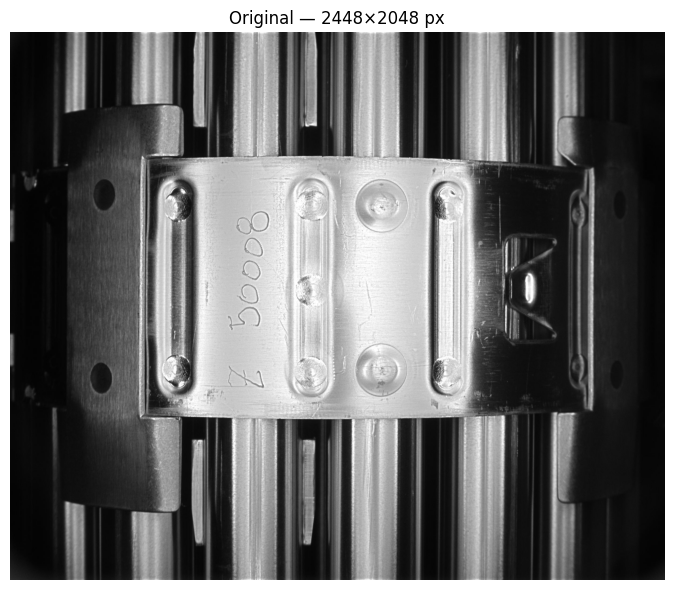

In [5]:
# ── Load image ────────────────────────────────────────────────────────────────
assert IMAGE_PATH is not None, 'Set IMAGE_PATH in the config cell first.'
assert Path(IMAGE_PATH).exists(), f'File not found: {IMAGE_PATH}'

IMAGE_PATH = Path(IMAGE_PATH)
PHOTO_ID   = extract_photo_id(IMAGE_PATH.name)
PARAMS     = get_params(PHOTO_ID)

original = cv2.imread(str(IMAGE_PATH))
assert original is not None, f'cv2.imread returned None for {IMAGE_PATH}'

print(f'File     : {IMAGE_PATH.name}')
print(f'Photo ID : {PHOTO_ID}')
print(f'Shape    : {original.shape[1]}×{original.shape[0]} px  (W×H)')
print(f'\nPARAMS   :')
for k, v in PARAMS.items():
    print(f'  {k:15s}: {v}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
ax.set_title(f'Original — {original.shape[1]}×{original.shape[0]} px')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Pipeline Steps
Each cell below matches one step in `digit_prediction_service.py → detect_numbers_in_image()`.

Rotated: 2048×2448 px  (W×H)


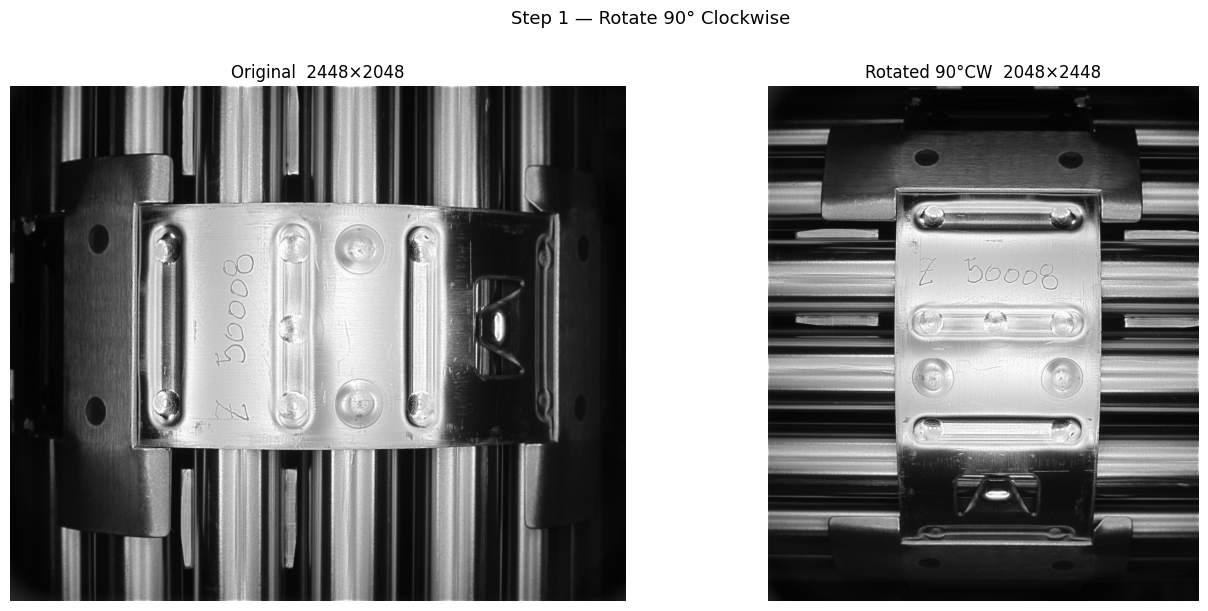

In [6]:
# ── Step 1 — Rotate 90° CW ────────────────────────────────────────────────────
rotated = cv2.rotate(original, cv2.ROTATE_90_CLOCKWISE)
print(f'Rotated: {rotated.shape[1]}×{rotated.shape[0]} px  (W×H)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original  {original.shape[1]}×{original.shape[0]}')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Rotated 90°CW  {rotated.shape[1]}×{rotated.shape[0]}')
axes[1].axis('off')
plt.suptitle('Step 1 — Rotate 90° Clockwise', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Rotated size  : 2048×2448 px
Crop source   : per-ID config
Crop requested: (800,600) → (1400,1100)
Crop clamped  : (800,600) → (1400,1100)
Crop result   : 600×500 px


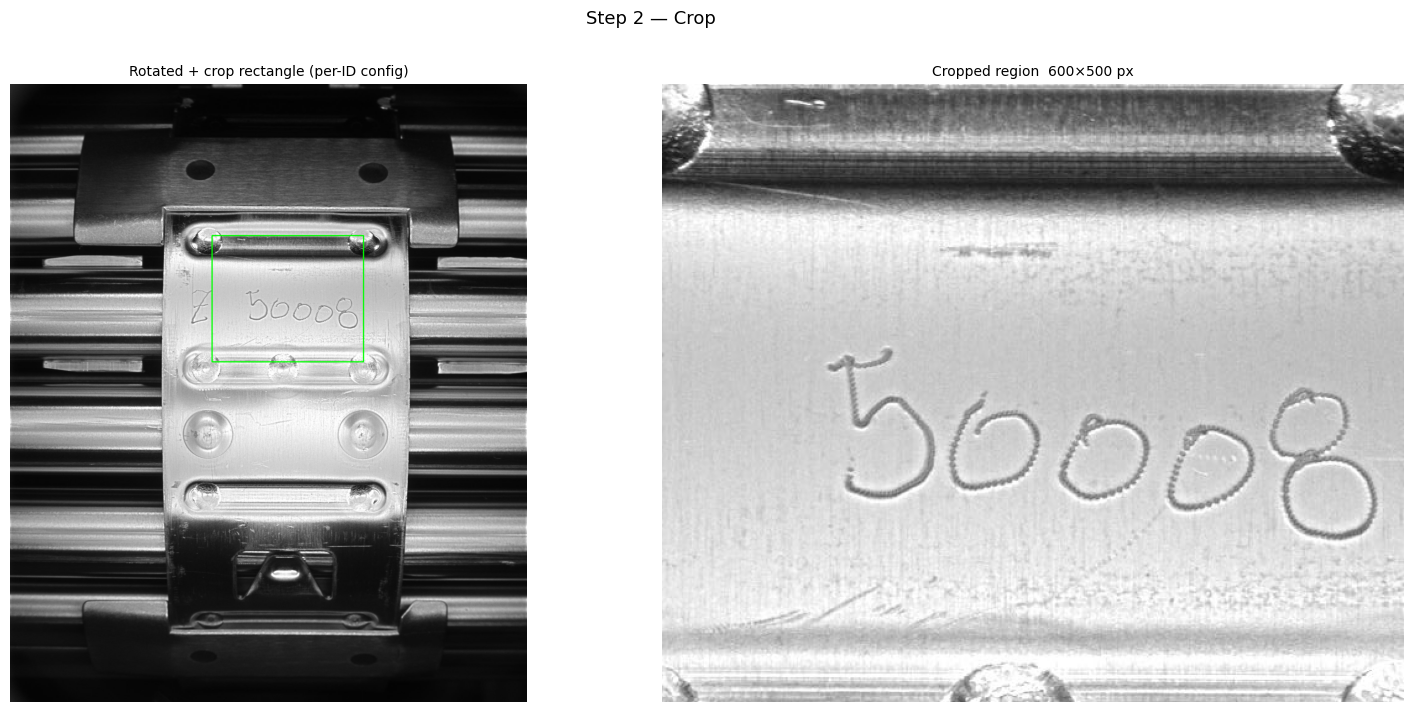


✓ Crop OK — 600×500 px


In [7]:
# ── Step 2 — Crop (per-ID override OR DEFAULT_CROP) ───────────────────────────
crop = PARAMS.get('crop', DEFAULT_CROP)
cx1, cy1, cx2, cy2 = crop['x1'], crop['y1'], crop['x2'], crop['y2']
source = 'per-ID config' if 'crop' in PARAMS else 'DEFAULT_CROP'

rH, rW = rotated.shape[:2]
# Clamp
cx1c = max(0, min(cx1, rW-1)); cx2c = max(0, min(cx2, rW))
cy1c = max(0, min(cy1, rH-1)); cy2c = max(0, min(cy2, rH))

print(f'Rotated size  : {rW}×{rH} px')
print(f'Crop source   : {source}')
print(f'Crop requested: ({cx1},{cy1}) → ({cx2},{cy2})')
print(f'Crop clamped  : ({cx1c},{cy1c}) → ({cx2c},{cy2c})')
print(f'Crop result   : {cx2c-cx1c}×{cy2c-cy1c} px')

if cx2c <= cx1c or cy2c <= cy1c:
    print('\n⛔  CROP FAILED — rectangle has zero area after clamping!')
    print('   The image is smaller than the crop window.')
    print('   → Update PHOTO_ID_PARAMS[\'' + PHOTO_ID + '\'][crop] or DEFAULT_CROP.')
else:
    cropped = rotated[cy1c:cy2c, cx1c:cx2c]
    annotated = rotated.copy()
    cv2.rectangle(annotated, (cx1c, cy1c), (cx2c, cy2c), (0,255,0), 4)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Rotated + crop rectangle ({source})', fontsize=10)
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Cropped region  {cx2c-cx1c}×{cy2c-cy1c} px', fontsize=10)
    axes[1].axis('off')
    plt.suptitle('Step 2 — Crop', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'\n✓ Crop OK — {cx2c-cx1c}×{cy2c-cy1c} px')

Rail-crop result : rows 93–500  (407/500 px kept)
Applied          : True


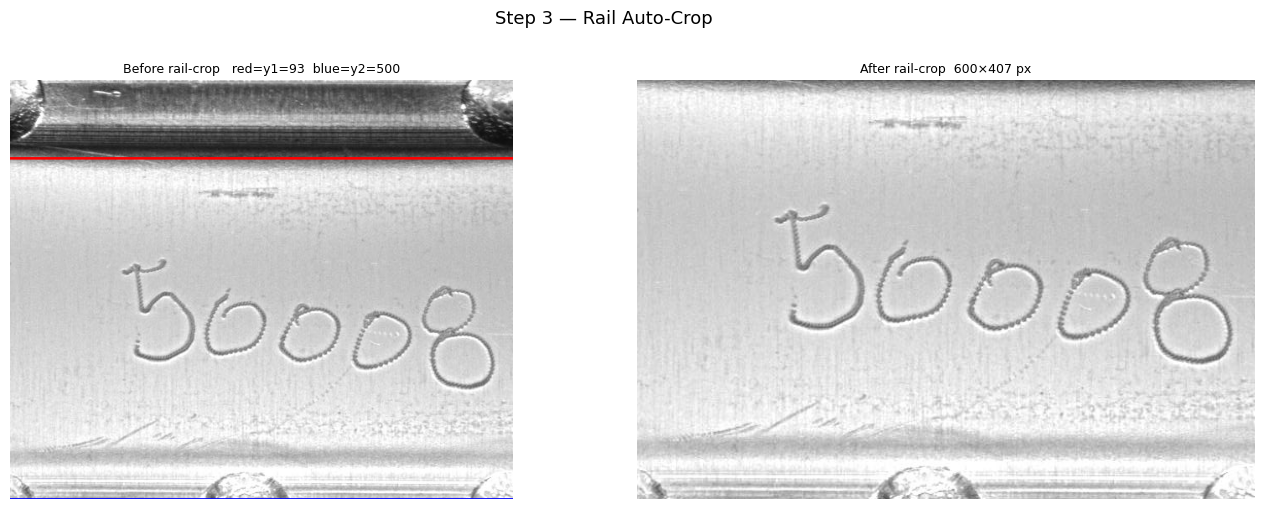

In [8]:
# ── Step 3 — Rail auto-crop ───────────────────────────────────────────────────
rail_result, rc_y1, rc_y2 = auto_crop_rails(cropped)
applied = (rc_y2 - rc_y1) > 30

print(f'Rail-crop result : rows {rc_y1}–{rc_y2}  '
      f'({rc_y2-rc_y1}/{cropped.shape[0]} px kept)')
print(f'Applied          : {applied}')

if applied:
    cropped = rail_result

# Visualise rail rows on the pre-crop image
gray_c = cv2.cvtColor(cropped if not applied else rotated[cy1c:cy2c, cx1c:cx2c],
                      cv2.COLOR_BGR2GRAY) if (cropped if not applied else rotated[cy1c:cy2c, cx1c:cx2c]).ndim == 3 \
    else (cropped if not applied else rotated[cy1c:cy2c, cx1c:cx2c])

pre_rail = rotated[cy1c:cy2c, cx1c:cx2c]
annotated_rail = pre_rail.copy()
if applied:
    cv2.line(annotated_rail, (0, rc_y1), (pre_rail.shape[1], rc_y1), (0,0,255), 2)
    cv2.line(annotated_rail, (0, rc_y2), (pre_rail.shape[1], rc_y2), (255,0,0), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(annotated_rail, cv2.COLOR_BGR2RGB))
title0 = f'Before rail-crop   red=y1={rc_y1}  blue=y2={rc_y2}' if applied else 'Before rail-crop (not applied)'
axes[0].set_title(title0, fontsize=9)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'After rail-crop  {cropped.shape[1]}×{cropped.shape[0]} px', fontsize=9)
axes[1].axis('off')
plt.suptitle('Step 3 — Rail Auto-Crop', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

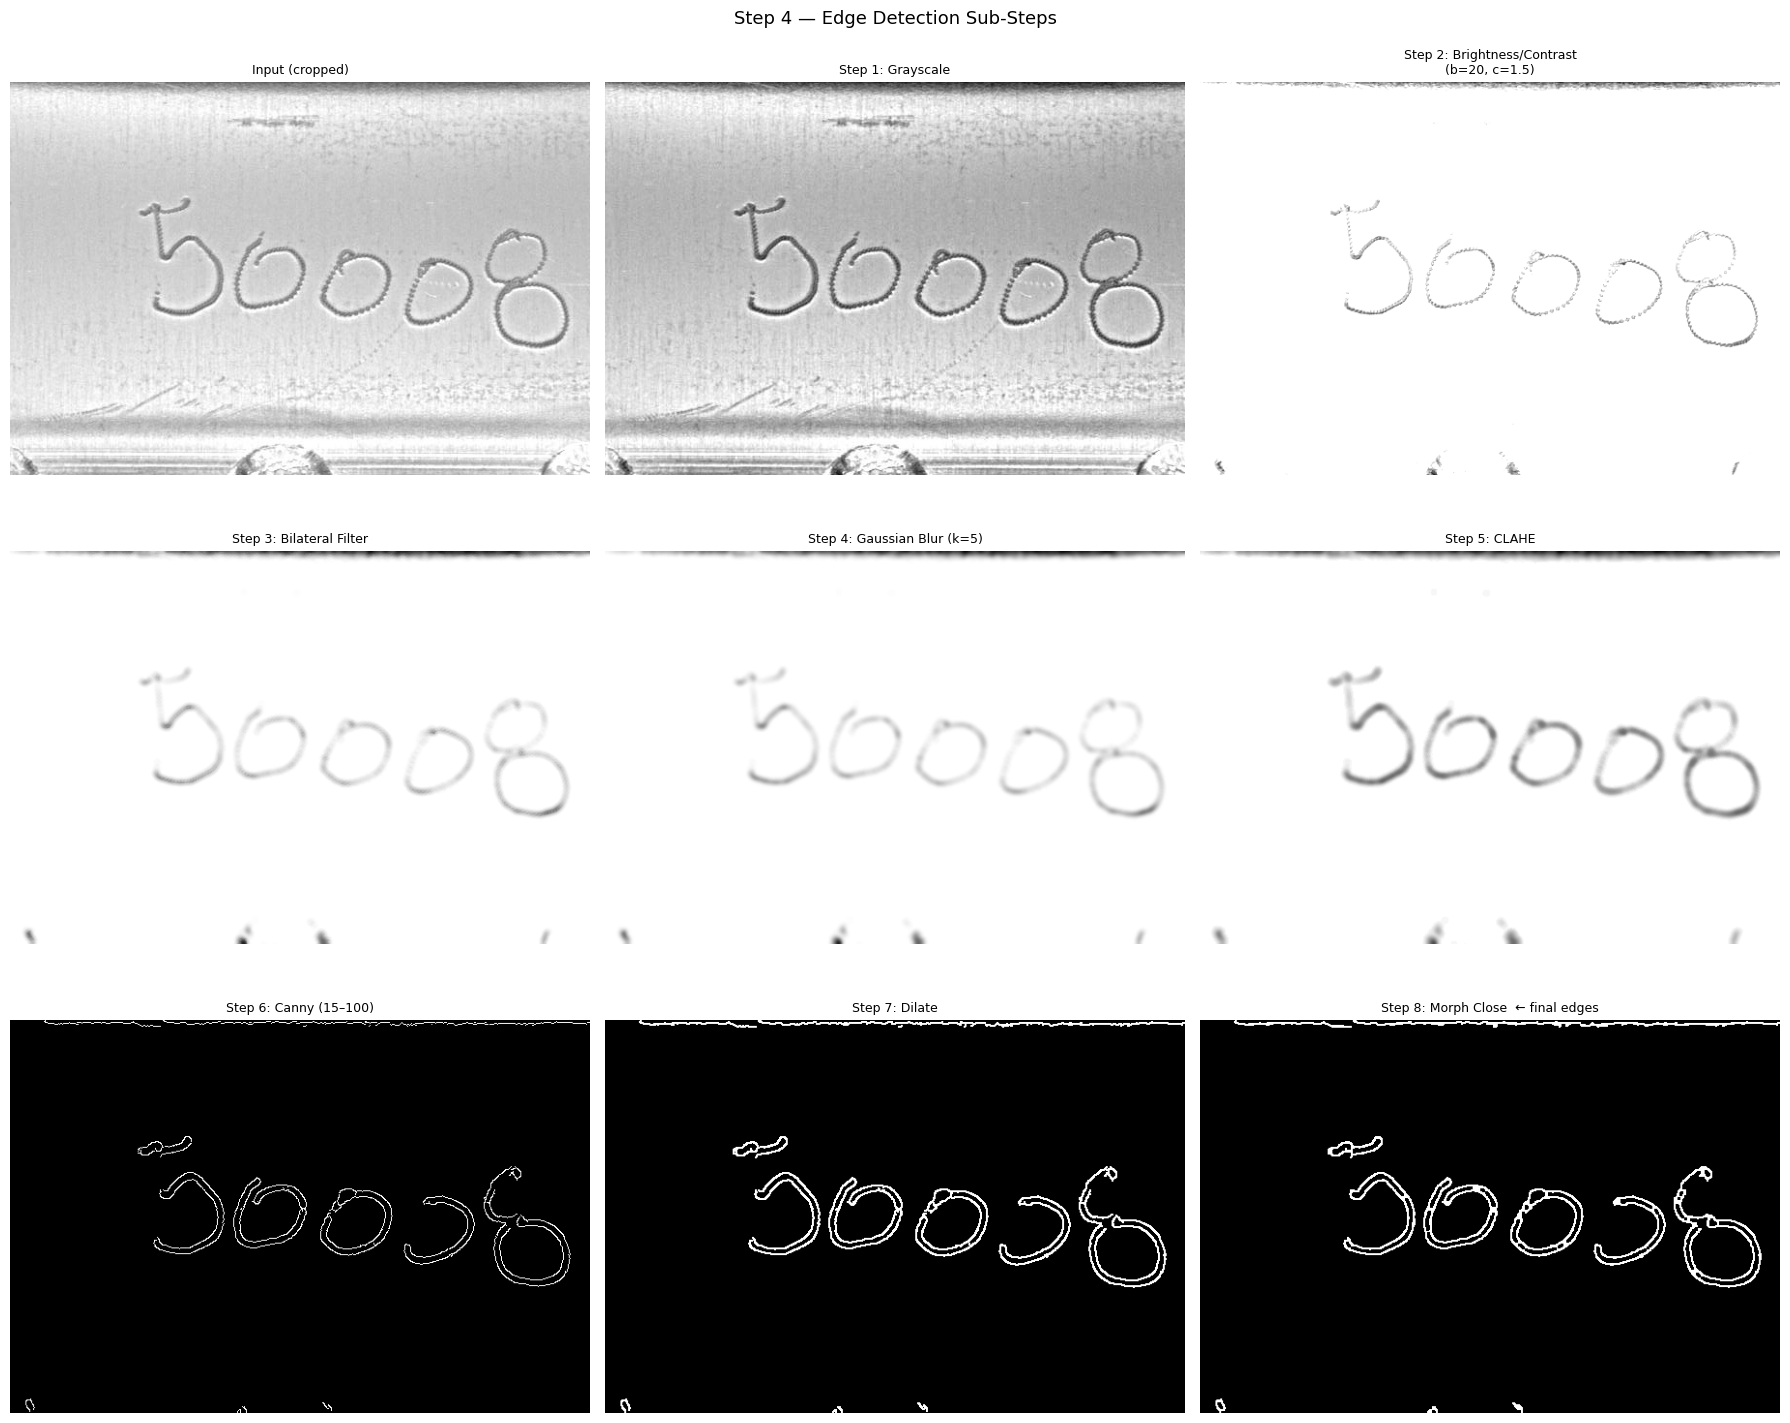

Edge coverage: 3.1%  (too low → fewer candidates; too high → noise)


In [9]:
# ── Step 4 — Edge Detection (all 8 sub-steps) ─────────────────────────────────
p = PARAMS
steps = preprocess_steps(
    cropped,
    brightness=p['brightness'],
    contrast=p['contrast'],
    canny_low=p['canny_low'],
    canny_high=p['canny_high'],
    gaussian_blur=p.get('gaussian_blur', 5),
    negative=p.get('negative', False),
)
edges = steps['8_close']   # final edge image passed to segmentation

labels = {
    '0_negative': 'Step 0: Negative (invert)',
    '1_gray':     'Step 1: Grayscale',
    '2_adj':      f'Step 2: Brightness/Contrast\n(b={p["brightness"]}, c={p["contrast"]})',
    '3_denoise':  'Step 3: Bilateral Filter',
    '4_blur':     f'Step 4: Gaussian Blur (k={p.get("gaussian_blur",5)})',
    '5_clahe':    'Step 5: CLAHE',
    '6_canny':    f'Step 6: Canny ({p["canny_low"]}–{p["canny_high"]})',
    '7_dilate':   'Step 7: Dilate',
    '8_close':    'Step 8: Morph Close  ← final edges',
}

# Always show cropped original as first panel
panels = [('original', cropped)] + [(k, steps[k]) for k in sorted(steps.keys())]
ncols = 3
nrows = -(-len(panels) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
axes = axes.flatten()
for i, (key, img) in enumerate(panels):
    if img.ndim == 3:
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        axes[i].imshow(img, cmap='gray')
    title = 'Input (cropped)' if key == 'original' else labels.get(key, key)
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')
for j in range(len(panels), len(axes)):
    axes[j].axis('off')
plt.suptitle('Step 4 — Edge Detection Sub-Steps', fontsize=13)
plt.tight_layout()
plt.show()

edge_pct = 100 * np.sum(edges > 0) / edges.size
print(f'Edge coverage: {edge_pct:.1f}%  (too low → fewer candidates; too high → noise)')

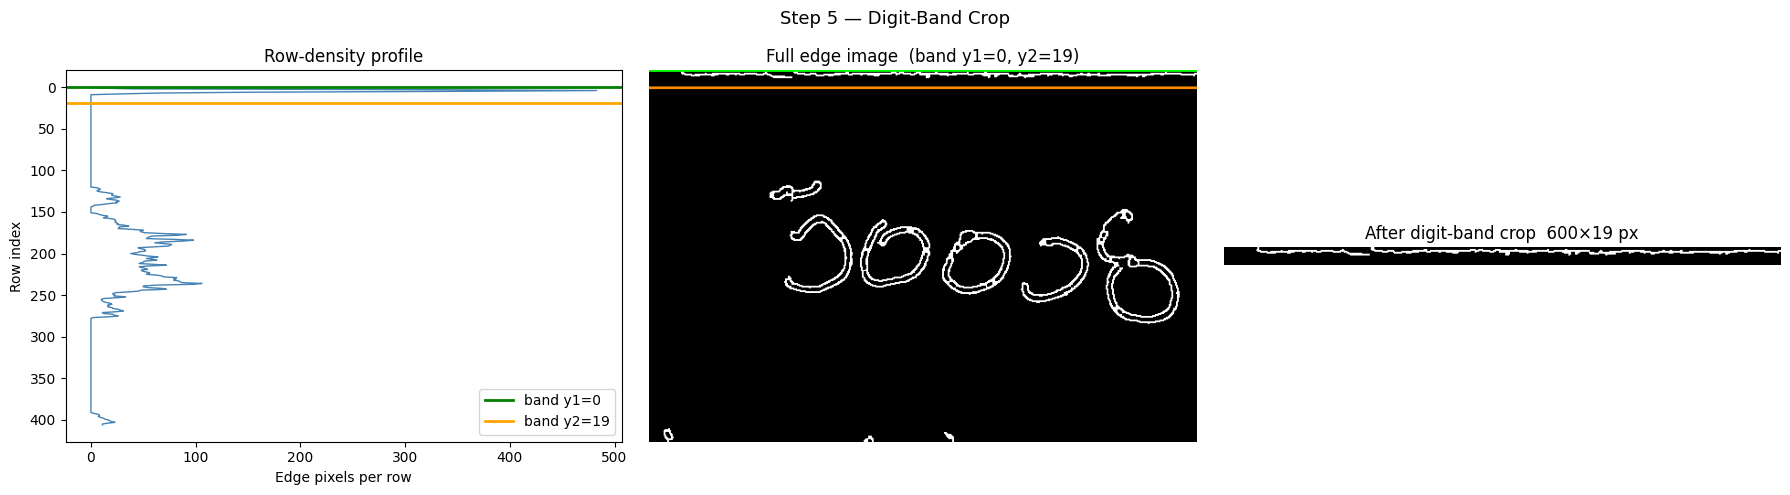

Band rows: 0–19  (19 px / 407 px total)  applied=True


In [10]:
# ── Step 5 — Digit-Band Crop ──────────────────────────────────────────────────
orig_h = edges.shape[0]
dy1, dy2 = find_digit_band(edges)
band_applied = (dy2 - dy1) < orig_h

# Row-density profile
row_density = np.sum(edges > 0, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Density profile
axes[0].plot(row_density, np.arange(orig_h), color='steelblue', linewidth=1)
axes[0].axhline(dy1, color='green',  linewidth=2, label=f'band y1={dy1}')
axes[0].axhline(dy2, color='orange', linewidth=2, label=f'band y2={dy2}')
axes[0].invert_yaxis()
axes[0].set_xlabel('Edge pixels per row')
axes[0].set_ylabel('Row index')
axes[0].set_title('Row-density profile')
axes[0].legend()

# 2. Full edge image with band markers
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
edges_ann = edges_rgb.copy()
cv2.line(edges_ann, (0, dy1), (edges.shape[1], dy1), (0,255,0), 2)
cv2.line(edges_ann, (0, dy2), (edges.shape[1], dy2), (255,140,0), 2)
axes[1].imshow(edges_ann)
axes[1].set_title(f'Full edge image  (band y1={dy1}, y2={dy2})')
axes[1].axis('off')

# 3. After band crop
if band_applied:
    edges   = edges[dy1:dy2, :]
    cropped = cropped[dy1:dy2, :, :] if cropped.ndim == 3 else cropped[dy1:dy2, :]
axes[2].imshow(edges, cmap='gray')
axes[2].set_title(f'After digit-band crop  {edges.shape[1]}×{edges.shape[0]} px'
                  + ('' if band_applied else '  (no change)'))
axes[2].axis('off')

plt.suptitle('Step 5 — Digit-Band Crop', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Band rows: {dy1}–{dy2}  ({dy2-dy1} px / {orig_h} px total)  applied={band_applied}')

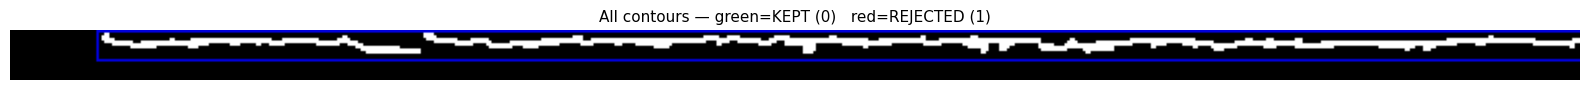

Total contours found: 1
  Kept    : 0
  Rejected: 1

⚠  NO DIGIT REGIONS KEPT — see Step 6B for rejection reasons.


In [11]:
# ── Step 6A — All contours (before filtering) ─────────────────────────────────
kept, rejected, closed = segment_digits_full(edges)

# Build annotated image: green=kept, red=rejected
ann = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
for (_, bbox, area, w, h, reason) in rejected:
    x1r, y1r, x2r, y2r = bbox
    cv2.rectangle(ann, (x1r, y1r), (x2r, y2r), (0, 0, 220), 1)
for (_, bbox) in kept:
    x1k, y1k, x2k, y2k = bbox
    cv2.rectangle(ann, (x1k, y1k), (x2k, y2k), (0, 220, 0), 2)

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(ann)
ax.set_title(f'All contours — green=KEPT ({len(kept)})   red=REJECTED ({len(rejected)})',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Total contours found: {len(kept) + len(rejected)}')
print(f'  Kept    : {len(kept)}')
print(f'  Rejected: {len(rejected)}')
if not kept:
    print('\n⚠  NO DIGIT REGIONS KEPT — see Step 6B for rejection reasons.')

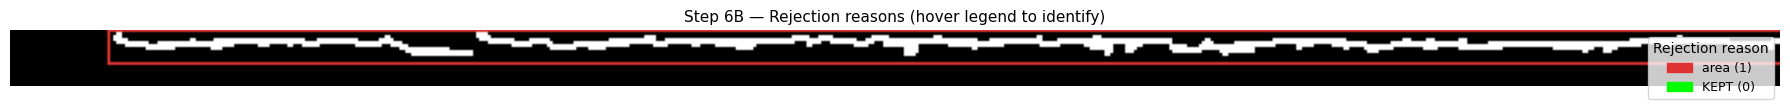

Rejection breakdown:
  area          :   1 contour(s)

Top-10 closest-to-valid rejected contours (for tuning):
  #     area     w     h  reason
------------------------------------------------------------
  1     4160   567    11  area=4160 (need 3000–3990)


In [12]:
# ── Step 6B — Rejection inspector ────────────────────────────────────────────
# Shows every rejected contour coloured by failure reason and prints stats.
# This is the most useful cell for debugging 'no regions detected'.

COLORS = {
    'area':        (220,  50,  50),
    'circularity': (220, 130,  50),
    'perim_ratio': (200, 200,  50),
    'width':       ( 50,  50, 220),
    'height':      (150,  50, 220),
    'aspect':      ( 50, 200, 200),
}

def reason_key(r):
    for k in COLORS: 
        if k in r: return k
    return 'area'

ann2 = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
counts = {}
for (_, bbox, area, w, h, reason) in rejected:
    key = reason_key(reason)
    counts[key] = counts.get(key, 0) + 1
    x1r, y1r, x2r, y2r = bbox
    cv2.rectangle(ann2, (x1r, y1r), (x2r, y2r), COLORS[key], 1)
for (_, bbox) in kept:
    x1k, y1k, x2k, y2k = bbox
    cv2.rectangle(ann2, (x1k, y1k), (x2k, y2k), (0, 255, 0), 2)

# Legend
legend_patches = [
    mpatches.Patch(color=[c/255 for c in COLORS[k]], label=f'{k} ({counts.get(k,0)})')
    for k in COLORS if counts.get(k, 0) > 0
]
legend_patches.append(mpatches.Patch(color='lime', label=f'KEPT ({len(kept)})'))

fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(ann2)
ax.legend(handles=legend_patches, loc='upper right', fontsize=9,
          framealpha=0.8, title='Rejection reason')
ax.set_title('Step 6B — Rejection reasons (hover legend to identify)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

# Print summary
print('Rejection breakdown:')
for k, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {k:14s}: {n:3d} contour(s)')

# Top-5 closest-to-valid rejected contours
if rejected:
    print('\nTop-10 closest-to-valid rejected contours (for tuning):')
    print(f'{"#":>3} {"area":>8} {"w":>5} {"h":>5}  reason')
    print('-' * 60)
    for i, (_, bbox, area, w, h, reason) in enumerate(rejected[:10]):
        print(f'{i+1:>3} {area:>8.0f} {w:>5} {h:>5}  {reason}')

In [13]:
# ── Step 6C — Kept digit regions ─────────────────────────────────────────────
if not kept:
    print('⛔  No digit regions — nothing to show. See 6B for why.')
else:
    ncols = max(len(kept), 1)
    fig, axes = plt.subplots(1, ncols, figsize=(3*ncols, 4))
    if ncols == 1: axes = [axes]
    for i, (dig_img, bbox) in enumerate(kept):
        axes[i].imshow(dig_img, cmap='gray')
        axes[i].set_title(f'Region {i+1}\n{bbox[2]-bbox[0]}×{bbox[3]-bbox[1]} px', fontsize=8)
        axes[i].axis('off')
    plt.suptitle(f'Step 6C — {len(kept)} Kept Digit Region(s)', fontsize=12)
    plt.tight_layout()
    plt.show()

⛔  No digit regions — nothing to show. See 6B for why.


In [14]:
# ── Step 7 — Top-5 Prediction (MNIST model) ───────────────────────────────────
# Loads the transfer-learning model from the service's model directory.
SERVICE_DIR = Path(
    r"C:\Users\carlosrodrig\Documents\3_Personal\2. MTTOIA"
    r"\1. Inspection webapp\Inspection_webapp\Conuar"
    r"\conuar_webapp\etl\digit_prediction_models"
)
MODEL_FILE = SERVICE_DIR / 'mnist_with_transfer_learning.keras'

if not kept:
    print('No regions to predict.')
elif not MODEL_FILE.exists():
    print(f'⚠  Model not found at:\n   {MODEL_FILE}')
    print('   Skipping prediction step — but segmentation debug is still valid.')
else:
    from tensorflow import keras
    MNIST_SIZE = 28
    model = keras.models.load_model(str(MODEL_FILE))
    print(f'Model loaded: {MODEL_FILE.name}')

    def predict_digit(digit_img):
        h, w = digit_img.shape[:2]
        scale = min(20.0/w, 20.0/h)
        nw, nh = max(1, int(w*scale)), max(1, int(h*scale))
        resized = cv2.resize(digit_img, (nw, nh), interpolation=cv2.INTER_AREA)
        canvas  = np.zeros((MNIST_SIZE, MNIST_SIZE), dtype=np.uint8)
        xo = (MNIST_SIZE - nw) // 2; yo = (MNIST_SIZE - nh) // 2
        canvas[yo:yo+nh, xo:xo+nw] = resized
        inp  = np.expand_dims(canvas.astype('float32')/255.0, axis=(0,-1))
        prob = model.predict(inp, verbose=0)[0]
        cls  = int(np.argmax(prob))
        return cls, float(prob[cls]), prob

    all_preds = []
    for dig_img, bbox in kept:
        cls, conf, prob = predict_digit(dig_img)
        all_preds.append((bbox, str(cls), conf, prob))

    # Top-5 by confidence → re-sort left→right
    top5 = sorted(all_preds, key=lambda r: r[2], reverse=True)[:5]
    top5 = sorted(top5, key=lambda r: r[0][0])

    detected = ''.join(r[1] for r in top5)
    print(f'\n🔢  Detected number : "{detected}"')
    print(f'    From {len(kept)} region(s), top-{len(top5)} selected:')
    for i, (bbox, digit, conf, prob) in enumerate(top5):
        bar = '█' * int(conf * 20)
        print(f'    Digit {i+1}: {digit}  conf={conf:.2f}  {bar}')

    # Show top-5 crops with bar charts
    fig, axes = plt.subplots(2, len(top5), figsize=(3*len(top5), 7))
    if len(top5) == 1: axes = np.array(axes).reshape(2,1)
    for i, (bbox, digit, conf, prob) in enumerate(top5):
        # Find the corresponding crop
        dig_img = next(img for img, b in kept if b == bbox)
        axes[0,i].imshow(dig_img, cmap='gray')
        axes[0,i].set_title(f'Pred: {digit}  conf={conf:.2f}', fontsize=9)
        axes[0,i].axis('off')
        axes[1,i].bar(range(10), prob, color=['green' if j==int(digit) else 'steelblue'
                                               for j in range(10)])
        axes[1,i].set_xticks(range(10))
        axes[1,i].set_ylim(0, 1)
        axes[1,i].set_xlabel('Digit class')
        axes[1,i].tick_params(labelsize=7)
    plt.suptitle(f'Step 7 — Top-5 Predictions → "{detected}"', fontsize=13)
    plt.tight_layout()
    plt.show()

No regions to predict.


---
## Diagnostics
Use the cells below when the pipeline produces no regions to find where the digits actually are.

Rotated size: 2048×2448  |  sweeping y from 0 to 2448 step 100, window 500px
Fixed x: 750–1400

    y1     y2  regions
------------------------
     0    500        0  
   100    600        0  
   200    700        0  
   300    800        0  
   400    900        0  
   500   1000        1  ▪
   600   1100        2  ▪▪ ◄ BEST
   700   1200        2  ▪▪
   800   1300        2  ▪▪
   900   1400        1  ▪
  1000   1500        0  
  1100   1600        0  
  1200   1700        0  
  1300   1800        0  
  1400   1900        0  
  1500   2000        0  
  1600   2100        0  
  1700   2200        0  
  1800   2300        0  
  1900   2400        0  

→ Best window: y1=600, y2=1100  (2 region(s))
  Update PHOTO_ID_PARAMS['198F']['crop'] to:
  {"x1": 750, "y1": 600, "x2": 1400, "y2": 1100}


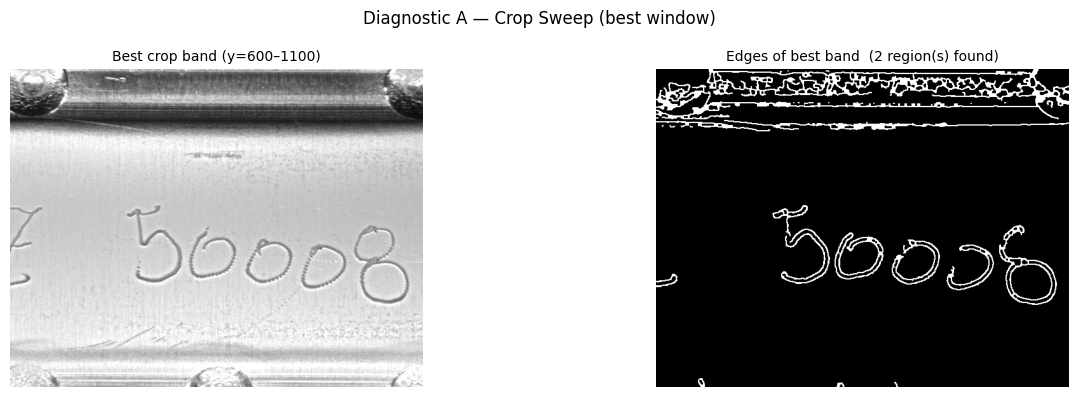

In [16]:
# ── Diagnostic A — Crop coordinate sweep ─────────────────────────────────────
# Sweeps y1 from 0 to the image height and y2 = y1 + window,
# counts digit-like contours in each band, and marks the best window.
#
# ▸ Use this when 'no regions detected' to find where the digits actually sit.

WINDOW_H = 500          # height of each sweep window (px)
STEP_Y   = 100          # step size (px)
FIXED_X1 = 750          # x1 for sweep (leave as DEFAULT_CROP or calibrate)
FIXED_X2 = 1400         # x2 for sweep

sweep_rotated = cv2.rotate(original, cv2.ROTATE_90_CLOCKWISE)
pH, pW = sweep_rotated.shape[:2]

print(f'Rotated size: {pW}×{pH}  |  sweeping y from 0 to {pH} step {STEP_Y}, window {WINDOW_H}px')
print(f'Fixed x: {FIXED_X1}–{FIXED_X2}\n')

results = []
for y1s in range(0, max(1, pH - WINDOW_H), STEP_Y):
    y2s   = min(y1s + WINDOW_H, pH)
    x1s   = max(0, min(FIXED_X1, pW-1))
    x2s   = max(0, min(FIXED_X2, pW))
    if x2s <= x1s or y2s <= y1s:
        continue
    band  = sweep_rotated[y1s:y2s, x1s:x2s]
    p_id  = PHOTO_ID
    p_par = get_params(p_id)
    edg   = preprocess_for_edge_detection(
        band,
        brightness=p_par['brightness'], contrast=p_par['contrast'],
        canny_low=p_par['canny_low'],   canny_high=p_par['canny_high'],
        gaussian_blur=p_par.get('gaussian_blur',5),
        negative=p_par.get('negative',False))
    kept_s, _, _ = segment_digits_full(edg)
    results.append((y1s, y2s, len(kept_s), band, edg))

counts  = [r[2] for r in results]
best_i  = int(np.argmax(counts))
best_y1 = results[best_i][0]
best_y2 = results[best_i][1]

print(f"{'y1':>6} {'y2':>6} {'regions':>8}")
print('-' * 24)
for y1s, y2s, n, _, _ in results:
    mark = ' ◄ BEST' if y1s == best_y1 else ''
    bar  = '▪' * n
    print(f"{y1s:>6} {y2s:>6} {n:>8}  {bar}{mark}")

print(f'\n→ Best window: y1={best_y1}, y2={best_y2}  ({counts[best_i]} region(s))')
if counts[best_i] > 0:
    print(f'  Update PHOTO_ID_PARAMS[\'{ PHOTO_ID }\'][\'crop\'] to:')
    print(f'  {{"x1": {FIXED_X1}, "y1": {best_y1}, "x2": {FIXED_X2}, "y2": {best_y2}}}')

# Show best crop + its edges
_, _, _, best_band, best_edg = results[best_i]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(best_band, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Best crop band (y={best_y1}–{best_y2})', fontsize=10)
axes[0].axis('off')
axes[1].imshow(best_edg, cmap='gray')
axes[1].set_title(f'Edges of best band  ({counts[best_i]} region(s) found)', fontsize=10)
axes[1].axis('off')
plt.suptitle('Diagnostic A — Crop Sweep (best window)', fontsize=12)
plt.tight_layout()
plt.show()

Canny sweep (gaussian_blur fixed to param value):
 canny_low  canny_high   regions
----------------------------------
         5          50         3  ▪▪▪ ◄
        10          75         2  ▪▪
        15         100         2  ▪▪
        20         100         2  ▪▪
        30         120         2  ▪▪
        50         150         1  ▪

Gaussian blur sweep (canny fixed to param value):
 gaussian_blur   regions
--------------------------
             3         2  ▪▪
             5         2  ▪▪
             7         2  ▪▪
            11         2  ▪▪


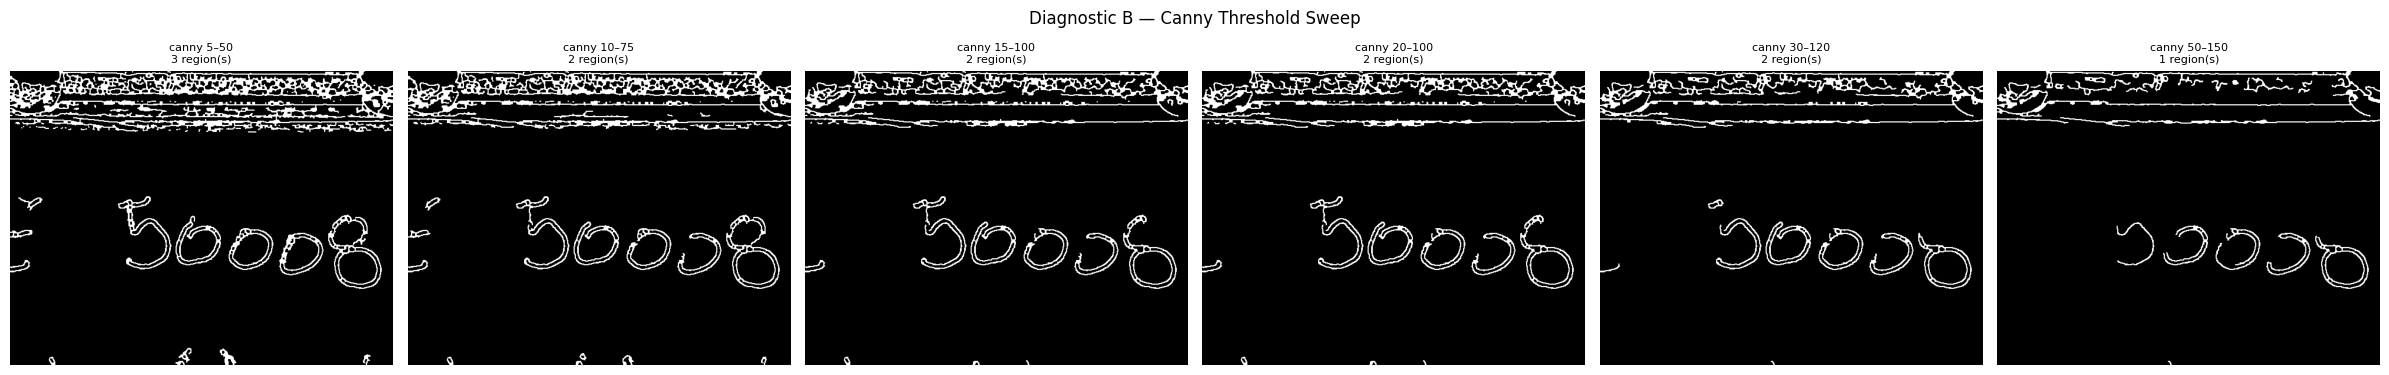

In [17]:
# ── Diagnostic B — Canny / gaussian sweep on the best crop band ───────────────
# Helps tune edge-detection params when the crop is correct but edges are wrong.

# Use best_band from Diagnostic A, or fall back to current cropped
sweep_img = best_band if counts[best_i] >= 0 else cropped

canny_pairs   = [(5,50), (10,75), (15,100), (20,100), (30,120), (50,150)]
gaussian_vals = [3, 5, 7, 11]

print('Canny sweep (gaussian_blur fixed to param value):')
print(f'{"canny_low":>10} {"canny_high":>11} {"regions":>9}')
print('-' * 34)
best_canny, best_cnt = canny_pairs[0], 0
for lo, hi in canny_pairs:
    p2 = PARAMS.copy()
    p2['canny_low']  = lo
    p2['canny_high'] = hi
    edg2 = preprocess_for_edge_detection(sweep_img, **{k:p2[k] for k in
               ['brightness','contrast','canny_low','canny_high','gaussian_blur','negative']})
    k2, _, _ = segment_digits_full(edg2)
    mark = ' ◄' if len(k2) > best_cnt else ''
    if len(k2) > best_cnt: best_cnt = len(k2); best_canny = (lo, hi)
    print(f'{lo:>10} {hi:>11} {len(k2):>9}  {"▪"*len(k2)}{mark}')

print(f'\nGaussian blur sweep (canny fixed to param value):')
print(f'{"gaussian_blur":>14} {"regions":>9}')
print('-' * 26)
for g in gaussian_vals:
    p3 = PARAMS.copy(); p3['gaussian_blur'] = g
    edg3 = preprocess_for_edge_detection(sweep_img, **{k:p3[k] for k in
               ['brightness','contrast','canny_low','canny_high','gaussian_blur','negative']})
    k3, _, _ = segment_digits_full(edg3)
    print(f'{g:>14} {len(k3):>9}  {"▪"*len(k3)}')

# Show canny grid
ncols = len(canny_pairs)
fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))
for i, (lo, hi) in enumerate(canny_pairs):
    p4 = PARAMS.copy(); p4['canny_low'] = lo; p4['canny_high'] = hi
    edg4 = preprocess_for_edge_detection(sweep_img, **{k:p4[k] for k in
               ['brightness','contrast','canny_low','canny_high','gaussian_blur','negative']})
    k4, _, _ = segment_digits_full(edg4)
    axes[i].imshow(edg4, cmap='gray')
    axes[i].set_title(f'canny {lo}–{hi}\n{len(k4)} region(s)', fontsize=8)
    axes[i].axis('off')
plt.suptitle('Diagnostic B — Canny Threshold Sweep', fontsize=12)
plt.tight_layout()
plt.show()

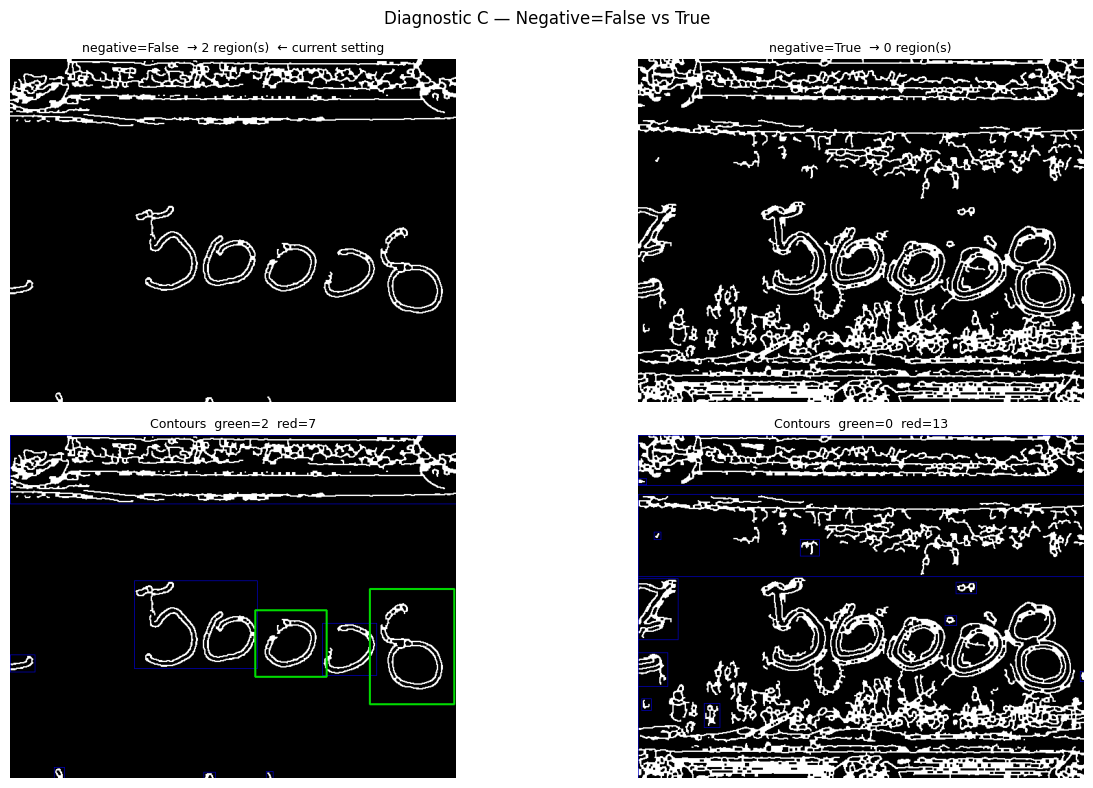

: 

In [ ]:
# ── Diagnostic C — Negative / non-negative comparison ────────────────────────
# For IDs like 33F/48F where negative=True, a wrong setting is a common cause
# of zero regions found.

sweep_img2 = best_band if counts[best_i] >= 0 else cropped

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col, neg in enumerate([False, True]):
    p5 = PARAMS.copy(); p5['negative'] = neg
    e5 = preprocess_for_edge_detection(sweep_img2, **{k:p5[k] for k in
             ['brightness','contrast','canny_low','canny_high','gaussian_blur','negative']})
    k5, _, _ = segment_digits_full(e5)
    label = f'negative={neg}  → {len(k5)} region(s)'
    if neg == PARAMS.get('negative', False):
        label += '  ← current setting'
    # edge image
    axes[0, col].imshow(e5, cmap='gray')
    axes[0, col].set_title(label, fontsize=9)
    axes[0, col].axis('off')
    # contour map
    ann5 = cv2.cvtColor(e5, cv2.COLOR_GRAY2BGR)
    k5r, rej5, _ = segment_digits_full(e5)
    for (_, bbox, *_) in rej5:
        cv2.rectangle(ann5, bbox[:2], bbox[2:], (0,0,200), 1)
    for (_, bbox) in k5r:
        cv2.rectangle(ann5, bbox[:2], bbox[2:], (0,220,0), 2)
    axes[1, col].imshow(ann5)
    axes[1, col].set_title(f'Contours  green={len(k5r)}  red={len(rej5)}', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('Diagnostic C — Negative=False vs True', fontsize=12)
plt.tight_layout()
plt.show()

---
## Interpretation Guide

### No contours at all in Step 6A
- **Step 2** crop is completely outside the image → the crop result is tiny or blank.
  - Run **Diagnostic A** to find where the digits actually are and read the suggested `crop` dict.
  - Update `PHOTO_ID_PARAMS['{photo_id}']['crop']` in `digit_prediction_service.py`.

### Contours exist but all rejected (Step 6B shows only red)
| Dominant rejection reason | Most likely fix |
|---|---|
| `area` too small | Edge image has noise but no solid digit blobs → tighten Canny (higher low threshold) |
| `area` too large | Blobs are merged → increase `gaussian_blur` or lower `canny_high` |
| `width` too small/large | Camera at different distance → digits are scaled differently; camera resolution differs |
| `height` too small/large | Same; also check `negative` setting |
| `circularity` / `perim_ratio` | Very noisy edge image → increase `gaussian_blur` or check `negative` |

### Contours found but prediction wrong
- The model may need fine-tuning with crops from the new camera.
- Check the probability bar charts in Step 7: if confidence is < 0.4, the digit images differ
  too much from training data.

### After finding the right params
1. Copy the `crop` dict from Diagnostic A into `digit_prediction_service.py → PHOTO_ID_PARAMS`.
2. Update `canny_low`/`canny_high`/`gaussian_blur`/`negative` if Diagnostics B/C show better values.
3. Restart the Django server and re-process the inspection.